# Week 1 — Day 2: Data Preprocessing and Medical Understanding

## 1. Introduction

In Day 1, we explored the ICU dataset structure, missing values, vital signs, laboratory values, and the sepsis label distribution.

The goal of Day 2 is to prepare the raw ICU time-series data for machine learning by:
- understanding the medical meaning of each variable
- separating vital signs, laboratory tests, and demographic features
- analyzing missing data more deeply
- applying basic preprocessing
- creating an initial patient-level feature dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
psv_files = list(Path("C:/Users/User/OneDrive/Desktop/icu-early-warning-system/data/raw").glob("*.psv"))

print(f"Number of PSV files found: {len(psv_files)}")
psv_files[:5]

Number of PSV files found: 20336


[WindowsPath('C:/Users/User/OneDrive/Desktop/icu-early-warning-system/data/raw/p000001.psv'),
 WindowsPath('C:/Users/User/OneDrive/Desktop/icu-early-warning-system/data/raw/p000002.psv'),
 WindowsPath('C:/Users/User/OneDrive/Desktop/icu-early-warning-system/data/raw/p000003.psv'),
 WindowsPath('C:/Users/User/OneDrive/Desktop/icu-early-warning-system/data/raw/p000004.psv'),
 WindowsPath('C:/Users/User/OneDrive/Desktop/icu-early-warning-system/data/raw/p000005.psv')]

In [5]:
sample_file = psv_files[0]

df_sample = pd.read_csv(sample_file, sep="|")

df_sample.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


In [7]:
vital_signs = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP",
    "Resp", "EtCO2"
]

lab_values = [
    "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2", "SaO2",
    "AST", "BUN", "Alkalinephos", "Calcium", "Chloride",
    "Creatinine", "Bilirubin_direct", "Glucose", "Lactate",
    "Magnesium", "Phosphate", "Potassium", "Bilirubin_total",
    "TroponinI", "Hct", "Hgb", "PTT", "WBC",
    "Fibrinogen", "Platelets"
]

demographics = [
    "Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"
]

target = "SepsisLabel"

## 2. Medical Variable Understanding

The ICU dataset contains different categories of clinical data:

### Vital signs
These are frequently measured bedside signals such as heart rate, oxygen saturation, temperature, blood pressure, and respiratory rate.

### Laboratory values
These are blood test results that reflect organ function, infection, inflammation, coagulation, kidney function, liver function, and metabolic status.

### Demographic and admission features
These include patient age, gender, ICU unit information, hospital admission time, and ICU length of stay.

### Target variable
The target variable is `SepsisLabel`, where:
- 0 means no sepsis at that hour
- 1 means sepsis is present or predicted according to the dataset definition

In [8]:
missing_summary = df_sample.isnull().mean().sort_values(ascending=False) * 100
missing_summary

EtCO2               100.000000
DBP                 100.000000
TroponinI           100.000000
Fibrinogen          100.000000
Unit1               100.000000
Unit2               100.000000
PTT                 100.000000
Bilirubin_direct    100.000000
Lactate             100.000000
Bilirubin_total      98.148148
AST                  98.148148
Alkalinephos         98.148148
Platelets            96.296296
Phosphate            96.296296
Magnesium            96.296296
Hct                  96.296296
Potassium            96.296296
WBC                  96.296296
Hgb                  96.296296
Creatinine           96.296296
Glucose              96.296296
Calcium              96.296296
Chloride             96.296296
HCO3                 96.296296
BUN                  96.296296
FiO2                 92.592593
SaO2                 92.592593
PaCO2                88.888889
pH                   87.037037
BaseExcess           87.037037
Temp                 81.481481
SBP                  22.222222
MAP     

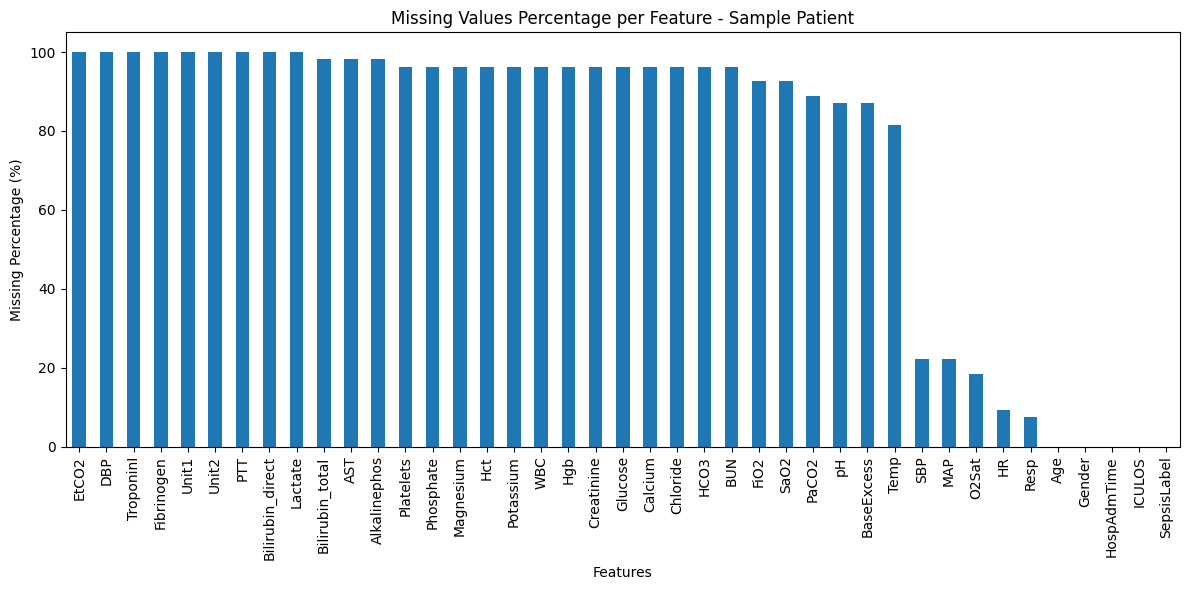

In [9]:
plt.figure(figsize=(12, 6))
missing_summary.plot(kind="bar")
plt.title("Missing Values Percentage per Feature - Sample Patient")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Missing Values Analysis

ICU datasets naturally contain many missing values because not all measurements are recorded every hour.

Vital signs are usually measured frequently, while laboratory tests are often measured only when clinically necessary.

Therefore, missing values in this dataset do not always mean data quality problems. In many cases, missingness itself may contain clinical information.

In [10]:
def load_patient_file(file_path):
    if file_path.suffix == ".csv":
        df = pd.read_csv(file_path)
    else:
        df = pd.read_csv(file_path, sep="|")
    
    df["Patient_ID"] = file_path.stem
    return df

In [11]:
all_files = psv_files

subset_files = all_files[:100]

df_list = [load_patient_file(file) for file in subset_files]

df = pd.concat(df_list, ignore_index=True)

df.shape

(3704, 42)

In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Number of patients:", df["Patient_ID"].nunique())
print("Sepsis label distribution:")
print(df["SepsisLabel"].value_counts())

Number of rows: 3704
Number of columns: 42
Number of patients: 100
Sepsis label distribution:
SepsisLabel
0    3569
1     135
Name: count, dtype: int64


In [13]:
sepsis_percentage = df["SepsisLabel"].mean() * 100
print(f"Percentage of septic time points: {sepsis_percentage:.2f}%")

Percentage of septic time points: 3.64%


## 4. Combined Dataset Overview

For Day 2, a subset of patient files is combined into one dataframe.  
This allows preprocessing to be tested on multiple patients without loading the full dataset immediately.

The dataset remains highly imbalanced because sepsis-positive time points are much less frequent than non-sepsis time points.

In [14]:
df[vital_signs + demographics].describe().T

,count,mean,std,min,25%,50%,75%,max
HR,3402.0,89.689888,17.550979,44.50,76.500,89.00,102.00,155.50
O2Sat,3236.0,97.281057,2.426899,79.00,96.000,98.00,99.00,100.00
Temp,1229.0,37.077917,0.873990,33.22,36.500,37.06,37.67,40.50
SBP,3058.0,121.685033,20.495106,69.00,106.000,120.00,136.00,220.50
MAP,3315.0,79.482365,14.057671,20.00,69.835,78.00,88.00,219.00
DBP,1719.0,61.899651,13.601167,32.00,53.000,60.00,69.00,287.00
Resp,3319.0,19.158406,5.630220,4.00,15.000,18.00,22.00,55.50
EtCO2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,3704.0,58.578958,17.308745,25.42,46.350,59.34,71.10,87.99
Gender,3704.0,0.609881,0.487843,0.00,0.000,1.00,1.00,1.00


In [15]:
df[lab_values].describe().T

,count,mean,std,min,25%,50%,75%,max
BaseExcess,371.0,-0.291105,5.410465,-14.00,-3.00,0.00,2.000,24.00
HCO3,307.0,23.845277,4.821961,12.00,21.00,23.00,26.000,48.00
FiO2,476.0,0.490483,0.191077,0.02,0.40,0.40,0.500,1.00
pH,397.0,7.364610,0.072618,6.98,7.33,7.37,7.410,7.53
PaCO2,320.0,44.662500,12.139995,22.00,37.00,43.00,49.625,100.00
SaO2,147.0,92.176871,10.066526,60.00,93.00,97.00,98.000,99.00
AST,63.0,235.476190,515.334525,8.00,22.00,42.00,110.500,2272.00
BUN,312.0,23.166667,19.333370,1.00,11.00,17.00,27.000,107.00
Alkalinephos,59.0,121.033898,79.566274,37.00,70.00,98.00,130.500,365.00
Calcium,185.0,8.150811,0.798172,5.90,7.60,8.10,8.600,11.10


In [16]:
df_sorted = df.sort_values(["Patient_ID", "ICULOS"]).copy()

features_to_fill = vital_signs + lab_values

df_sorted[features_to_fill] = (
    df_sorted
    .groupby("Patient_ID")[features_to_fill]
    .ffill()
)

In [17]:
for col in features_to_fill:
    median_value = df_sorted[col].median()
    df_sorted[col] = df_sorted[col].fillna(median_value)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [18]:
df_sorted[features_to_fill].isnull().sum().sort_values(ascending=False)

EtCO2               3704
HR                     0
O2Sat                  0
Temp                   0
MAP                    0
SBP                    0
DBP                    0
Resp                   0
BaseExcess             0
HCO3                   0
FiO2                   0
pH                     0
PaCO2                  0
SaO2                   0
AST                    0
BUN                    0
Alkalinephos           0
Calcium                0
Chloride               0
Creatinine             0
Bilirubin_direct       0
Glucose                0
Lactate                0
Magnesium              0
Phosphate              0
Potassium              0
Bilirubin_total        0
TroponinI              0
Hct                    0
Hgb                    0
PTT                    0
WBC                    0
Fibrinogen             0
Platelets              0
dtype: int64

## 5. Preprocessing Strategy

Because the dataset is time-series ICU data, forward filling is applied within each patient.

This means that if a clinical measurement was recorded at a previous hour, it is carried forward to the next hour until a new value is available.

Remaining missing values are filled using the median value of each feature.

This is a simple baseline preprocessing strategy. More advanced imputation methods can be tested later.

In [19]:
patient_features = df_sorted.groupby("Patient_ID").agg({
    "HR": ["mean", "max", "min"],
    "O2Sat": ["mean", "min"],
    "Temp": ["mean", "max"],
    "SBP": ["mean", "min"],
    "MAP": ["mean", "min"],
    "Resp": ["mean", "max"],
    "Age": "first",
    "Gender": "first",
    "ICULOS": "max",
    "SepsisLabel": "max"
})

In [20]:
patient_features.columns = [
    "_".join(col).strip() for col in patient_features.columns.values
]

patient_features = patient_features.reset_index()

patient_features.head()

,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


In [21]:
patient_features.shape

(100, 18)

In [22]:
processed_data_path = Path("../data/processed")
processed_data_path.mkdir(parents=True, exist_ok=True)

In [23]:
patient_features.to_csv(
    processed_data_path / "day2_patient_level_features.csv",
    index=False
)

## 6. Processed Dataset Export

The processed patient-level feature table is saved in:

`data/processed/day2_patient_level_features.csv`

This file will be used later for baseline machine learning models.

## 7. Medical Interpretation

Several features are clinically important for early warning prediction:

- High heart rate may indicate physiological stress, infection, pain, or shock.
- Low oxygen saturation may indicate respiratory compromise.
- Abnormal temperature may reflect infection or systemic inflammation.
- Low blood pressure or MAP may indicate hemodynamic instability.
- High respiratory rate is often an early sign of deterioration.
- Longer ICU stay may increase the chance of observing sepsis or clinical worsening.

These features are not diagnostic alone, but together they can help a machine learning model detect patterns related to early clinical deterioration.

## 8. Conclusion

Day 2 focused on preparing ICU time-series data for machine learning.

Completed tasks:
- grouped variables into vital signs, laboratory values, demographics, and target label
- analyzed missing values by feature
- combined multiple patient files
- applied baseline preprocessing using forward fill and median imputation
- created an initial patient-level feature table
- saved the processed dataset for future modeling

The project is now ready for Day 3, where baseline machine learning models can be trained and evaluated.